In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("16-diabetes.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df['Insulin'].value_counts()

,count
Insulin,
0,374
105,11
130,9
140,9
120,8
...,...
178,1
127,1
510,1


In [10]:
df['BloodPressure'].value_counts()

,count
BloodPressure,
70,57
74,52
78,45
68,45
72,44
64,43
80,40
76,39
60,37


In [11]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [12]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    zero_percentage = 100 * zero_count /len(df)
    print(f"{col}: {zero_count} %{zero_percentage:.2f}")

Glucose: 5 %0.65
BloodPressure: 35 %4.56
SkinThickness: 227 %29.56
Insulin: 374 %48.70
BMI: 11 %1.43


In [13]:
sns.set_theme(style="darkgrid")

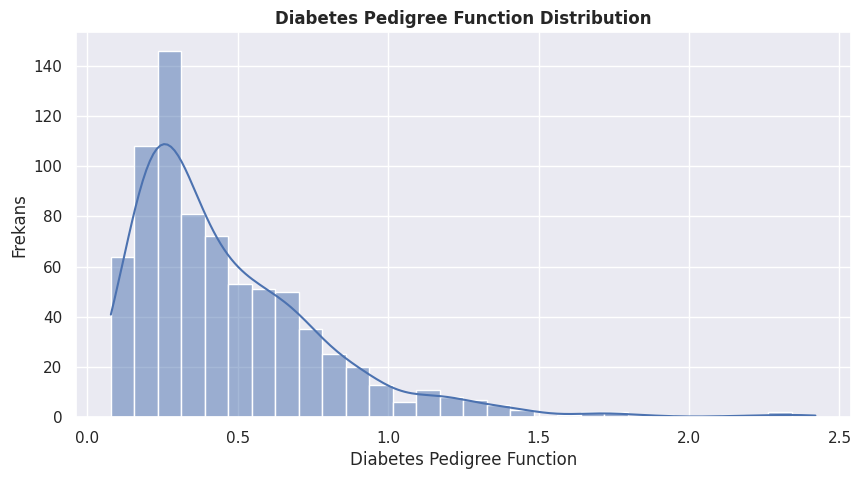

In [14]:
fig,ax = plt.subplots(figsize=(10,5))
sns.histplot(df['DiabetesPedigreeFunction'], bins=30, kde=True)
plt.title('Diabetes Pedigree Function Distribution',fontweight="bold")
plt.xlabel('Diabetes Pedigree Function')
plt.ylabel('Frekans')
plt.show()

/tmp/ipykernel_1962/3476550996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Outcome', y='DiabetesPedigreeFunction', data=df,palette="Dark2")


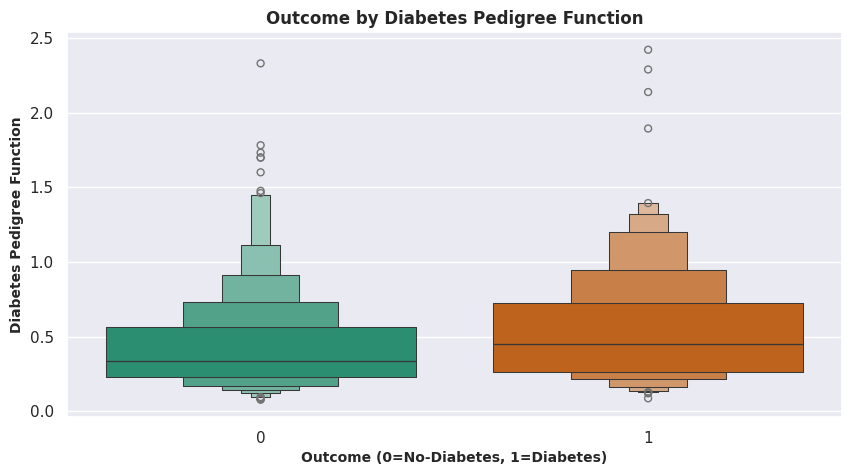

In [15]:
fig,ax = plt.subplots(figsize=(10,5))
sns.boxenplot(x='Outcome', y='DiabetesPedigreeFunction', data=df,palette="Dark2")
plt.title('Outcome by Diabetes Pedigree Function',fontweight='bold')
plt.xlabel('Outcome (0=No-Diabetes, 1=Diabetes)',fontweight='bold',fontsize=10)
plt.ylabel('Diabetes Pedigree Function',fontweight='bold',fontsize=10)
plt.show()

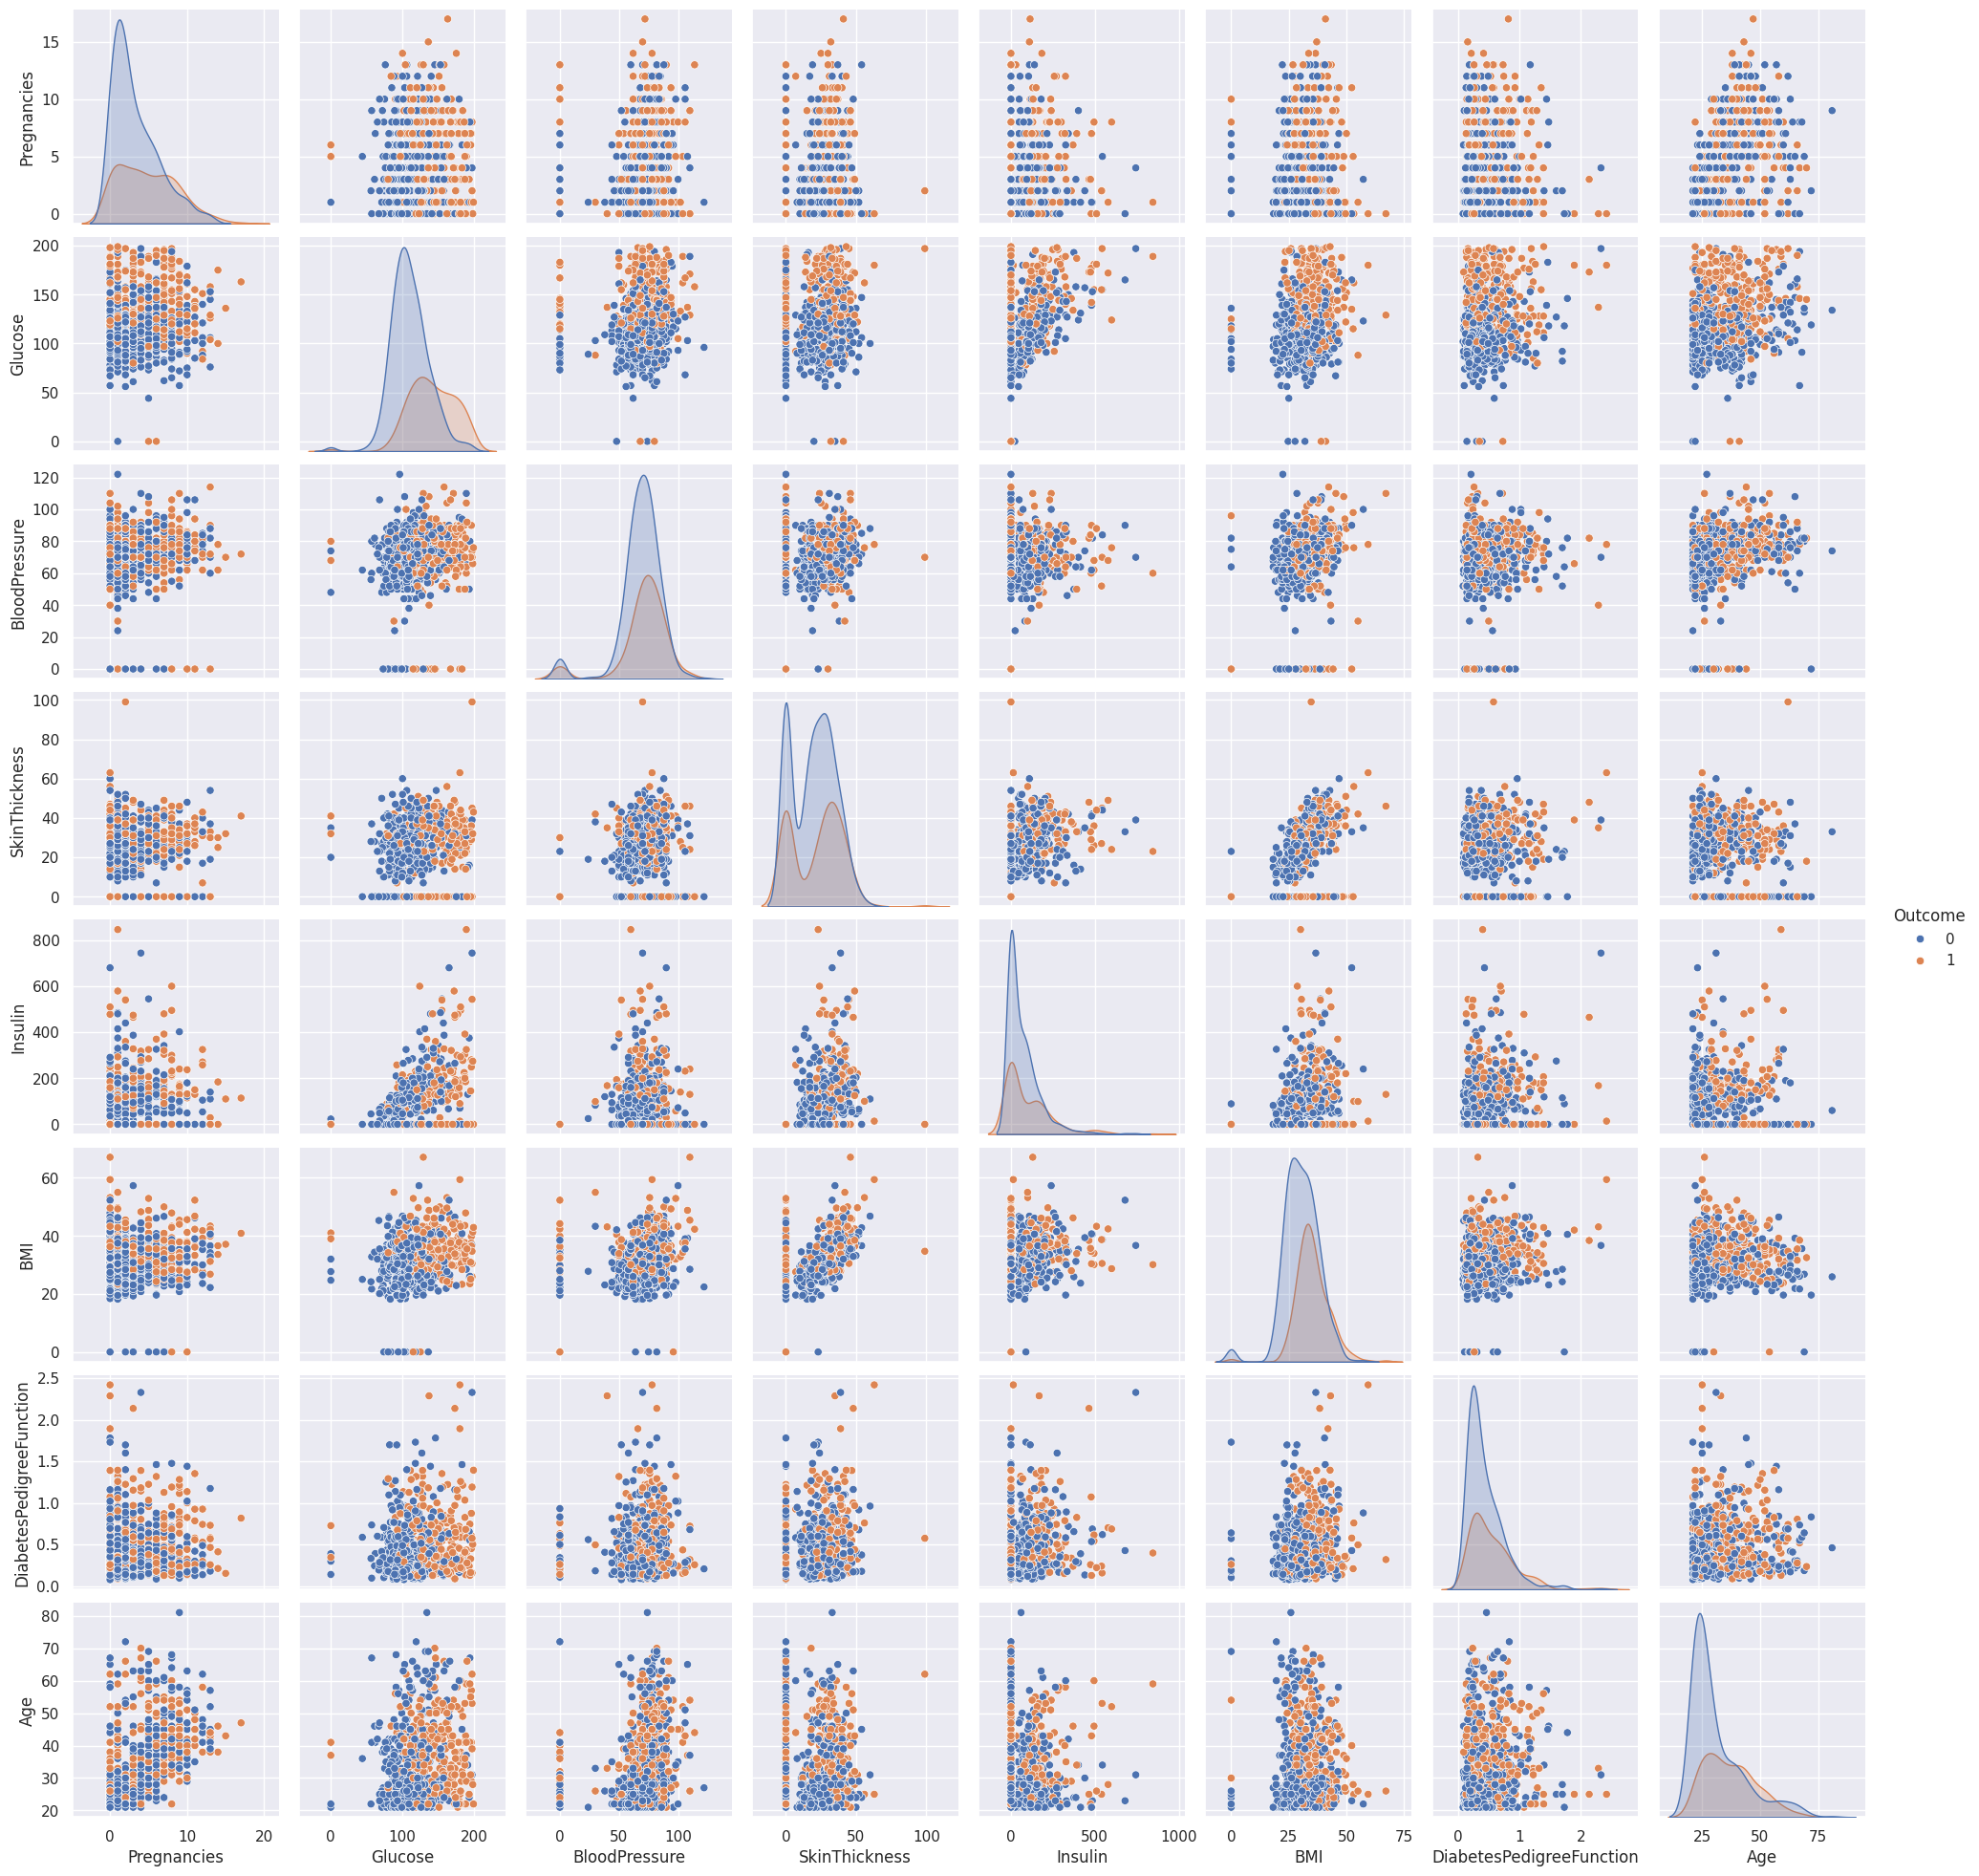

In [16]:
sns.pairplot(df, hue='Outcome')
plt.show()

In [17]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [18]:
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=15)

In [20]:
columns_to_fill = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

In [21]:
medians = {}
for col in columns_to_fill:
    median_value = X_train[X_train[col] != 0][col].median()
    medians[col] = median_value
    X_train[col] = X_train[col].replace(0, median_value)

for col in columns_to_fill:
    X_test[col] = X_test[col].replace(0, medians[col])

In [22]:
for col in columns_to_fill:
    median_value = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median_value)

In [23]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [25]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,71.487013,29.376623,144.402597,32.483117,0.479565,33.064935
std,3.304818,32.320876,11.813495,10.513035,104.291511,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,64.000000,23.250000,108.250000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,129.500000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


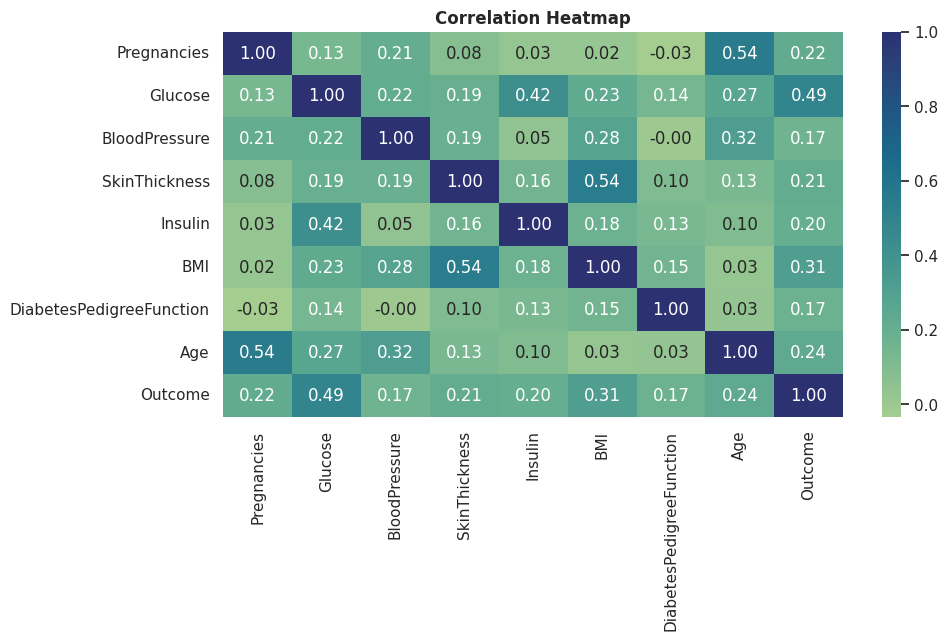

In [26]:
fig,ax = plt.subplots(figsize=(10,5))
sns.heatmap(df.corr(), annot=True,cmap='crest',fmt=".2f")
plt.title('Correlation Heatmap',fontweight='bold')
plt.show()

In [27]:
df["Age Classification"] = ["Young" if age < 30 else "Middle-aged" if age < 50 else "Old" for age in df["Age"]]

In [28]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome',
       'Age Classification'],
      dtype='object')

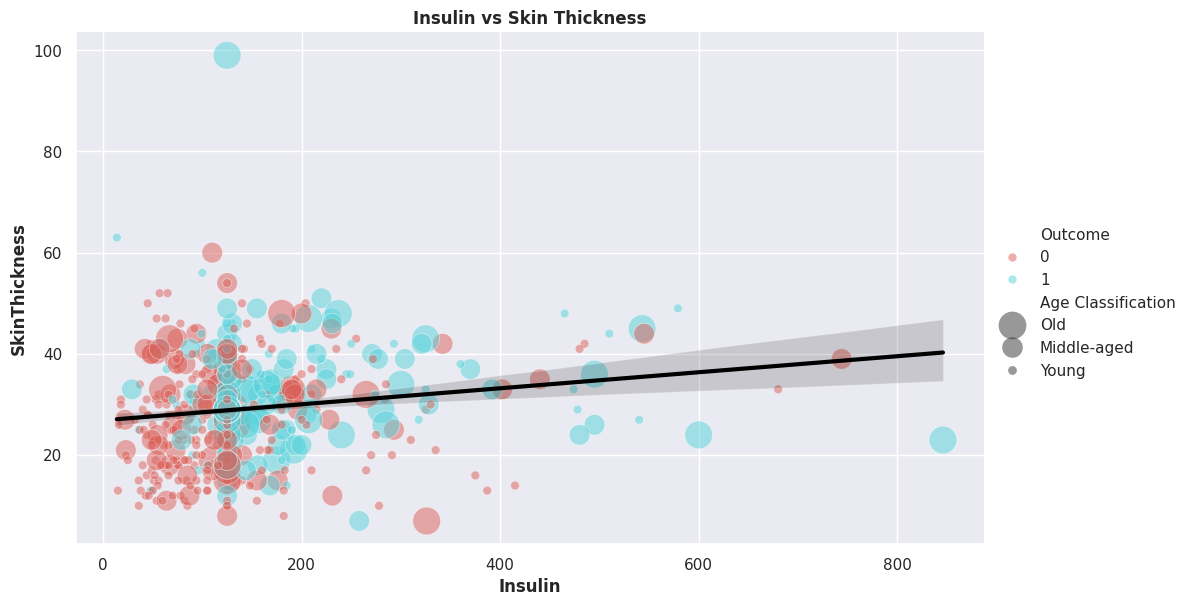

In [29]:
sns.relplot(x="Insulin", y="SkinThickness", hue="Outcome", size="Age Classification",
            sizes=(40, 400), alpha=.5, palette="hls",
            height=6, data=df,aspect=1.7)
plt.title('Insulin vs Skin Thickness',fontweight='bold')
plt.xlabel('Insulin',fontweight='bold')
plt.ylabel('Skin Thickness',fontweight='bold')

sns.regplot(
    data=df,
    x="Insulin",
    y="SkinThickness",
    scatter=False,
    color="black",
    line_kws={"linewidth":3}
)
plt.show()


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [32]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [33]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


In [34]:
#hyperparameter tuning

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
adaboost_param = {
        "n_estimators" : [50, 70, 100, 120, 150, 200],
        "learning_rate" : [0.001, 0.01, 0.1, 1, 10]
}

In [37]:
grid = GridSearchCV(estimator = AdaBoostClassifier(), param_grid = adaboost_param, cv = 5, verbose = 1, n_jobs = -1)

In [38]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10],
                         'n_estimators': [50, 70, 100, 120, 150, 200]},
             verbose=1)

In [39]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 150}

In [40]:
ada = AdaBoostClassifier(learning_rate=1, n_estimators=150)

In [41]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154

0.7597402597402597
[[87 21]
 [16 30]]


In [42]:
# missing value drop and fit model with more down size

In [43]:
df2 = pd.read_csv("16-diabetes.csv")

In [44]:
df2.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [45]:
df2.shape

(768, 9)

In [46]:
columns_to_check2 = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns_to_check2:
    df2[col].replace(0, np.nan, inplace=True)

/tmp/ipykernel_1962/3039475623.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[col].replace(0, np.nan, inplace=True)


In [47]:
df2.dropna(inplace=True)

In [48]:
df2.shape

(392, 9)

In [49]:
X = df2.drop("Outcome",axis=1)
y = df2["Outcome"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=15)

In [51]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [53]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8227848101265823
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        56
           1       0.76      0.57      0.65        23

    accuracy                           0.82        79
   macro avg       0.80      0.75      0.77        79
weighted avg       0.82      0.82      0.81        79

[[52  4]
 [10 13]]


In [54]:
adaboost_param

{'n_estimators': [50, 70, 100, 120, 150, 200],
 'learning_rate': [0.001, 0.01, 0.1, 1, 10]}

In [55]:
# hyper parametre tuning

In [56]:
grid = GridSearchCV(estimator = AdaBoostClassifier(), param_grid = adaboost_param, cv = 3, verbose = 1, n_jobs = -1)

In [57]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


GridSearchCV(cv=3, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10],
                         'n_estimators': [50, 70, 100, 120, 150, 200]},
             verbose=1)

In [58]:
grid.best_params_

{'learning_rate': 0.1, 'n_estimators': 50}

In [59]:
ada = AdaBoostClassifier(learning_rate=1, n_estimators=50)

In [60]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [61]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8227848101265823
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        56
           1       0.74      0.61      0.67        23

    accuracy                           0.82        79
   macro avg       0.79      0.76      0.77        79
weighted avg       0.82      0.82      0.82        79

[[51  5]
 [ 9 14]]


In [62]:
#Accuray has not changed.

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [64]:
models = {
    "LogisticClassifier" : LogisticRegression(),
    "K-Neighbors Classifier"  : KNeighborsClassifier(),
    "Decision Tree Classifier" : DecisionTreeClassifier(),
    "Random Forest Classifier" : RandomForestClassifier(),
    "AdaBoost Classifier" : AdaBoostClassifier()
}


In [65]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(list(models.keys())[i])
    print(accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("\n")
    print("-----------------------------------")
    print("\n")

LogisticClassifier
0.7721518987341772
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        56
           1       0.65      0.48      0.55        23

    accuracy                           0.77        79
   macro avg       0.73      0.69      0.70        79
weighted avg       0.76      0.77      0.76        79

[[50  6]
 [12 11]]


-----------------------------------


K-Neighbors Classifier
0.7721518987341772
              precision    recall  f1-score   support

           0       0.82      0.88      0.84        56
           1       0.63      0.52      0.57        23

    accuracy                           0.77        79
   macro avg       0.72      0.70      0.71        79
weighted avg       0.76      0.77      0.77        79

[[49  7]
 [11 12]]


-----------------------------------


Decision Tree Classifier
0.6962025316455697
              precision    recall  f1-score   support

           0       0.82      0.73      0.77      

In [66]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [67]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7721518987341772
              precision    recall  f1-score   support

           0       0.82      0.88      0.84        56
           1       0.63      0.52      0.57        23

    accuracy                           0.77        79
   macro avg       0.72      0.70      0.71        79
weighted avg       0.76      0.77      0.77        79

[[49  7]
 [11 12]]


In [68]:
params = {"n_neighbors":[2,3,4,5,6,7], "algorithm":["auto", "ball_tree", "kd_tree", "brute"]}

In [69]:
grid = GridSearchCV(estimator = KNeighborsClassifier(), param_grid = params, cv = 5, verbose = 1, n_jobs = -1)

In [70]:
X_train

array([[-0.13830124, -0.09654753, -0.03992665, ...,  1.38763036,
        -0.232197  , -0.1271859 ],
       [ 1.07255993,  2.38045048, -0.03992665, ..., -1.1352269 ,
        -1.07552167,  2.22560293],
       [ 1.37527522, -0.75708033,  0.27249937, ...,  0.89156292,
         0.37768139,  1.09626429],
       ...,
       [-0.44101653,  1.68689104,  1.36599042, ...,  1.61440404,
         0.33391021, -0.69185522],
       [ 1.07255993,  0.33279879,  1.36599042, ..., -0.10057196,
        -0.7866319 ,  0.53159497],
       [-0.13830124,  1.1584648 , -0.03992665, ...,  0.33880206,
        -0.54734947,  0.34337186]])

In [71]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [2, 3, 4, 5, 6, 7]},
             verbose=1)

In [72]:
y_pred = grid.predict(X_test)

In [73]:
grid.best_params_

{'algorithm': 'auto', 'n_neighbors': 3}

In [74]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7341772151898734
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        56
           1       0.56      0.43      0.49        23

    accuracy                           0.73        79
   macro avg       0.67      0.65      0.65        79
weighted avg       0.72      0.73      0.72        79

[[48  8]
 [13 10]]


In [75]:
# accuary is down

In [76]:
#I'm going to replace the missing observations with the mean instead of the median.

In [77]:
df3 = pd.read_csv("16-diabetes.csv")

In [78]:
for col in columns_to_fill:
    mean_value = df3[df3[col] != 0][col].mean()
    df3[col] = df3[col].replace(0, mean_value)

In [79]:
df3.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [80]:
df3.shape

(768, 9)

In [81]:
X = df3.drop("Outcome",axis=1)
y = df3["Outcome"]

In [82]:
X_train2, X_test2, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=15)

In [83]:
X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

In [84]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train2, y_train)

    y_pred = model.predict(X_test2)
    print(list(models.keys())[i])
    print(accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("\n")
    print("-----------------------------------")
    print("\n")

LogisticClassifier
0.7467532467532467
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.58      0.57      0.57        46

    accuracy                           0.75       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.75      0.75      0.75       154

[[89 19]
 [20 26]]


-----------------------------------


K-Neighbors Classifier
0.7207792207792207
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       108
           1       0.53      0.59      0.56        46

    accuracy                           0.72       154
   macro avg       0.67      0.68      0.68       154
weighted avg       0.73      0.72      0.72       154

[[84 24]
 [19 27]]


-----------------------------------


Decision Tree Classifier
0.6688311688311688
              precision    recall  f1-score   support

           0       0.81      0.69      0.74      

In [85]:
# Again accuray is down , I will research outlier

In [86]:
def outlier(df,kolon):
  Q1 = df[kolon].quantile(0.25)
  Q3 = df[kolon].quantile(0.75)
  IQR = Q3 - Q1

  alt_sinir = Q1 - 1.5 * IQR
  ust_sinir = Q3 + 1.5 * IQR

  aykiri_veriler_indices = df[(df[kolon] < alt_sinir) | (df[kolon] > ust_sinir)].index
  return aykiri_veriler_indices

In [87]:
df3.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [88]:
columns_outlier = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', "DiabetesPedigreeFunction"]
for col in columns_outlier:
    idx_to_drop = outlier(df3,col)
    df3.drop(index=idx_to_drop, inplace=True)

In [89]:
df3.shape

(467, 9)

In [90]:
X = df3.drop("Outcome",axis=1)
y = df3["Outcome"]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=15)

In [92]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [93]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(list(models.keys())[i])
    print(accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("\n")
    print("----------------------------------")
    print("\n")

LogisticClassifier
0.723404255319149
              precision    recall  f1-score   support

           0       0.78      0.80      0.79        61
           1       0.61      0.58      0.59        33

    accuracy                           0.72        94
   macro avg       0.70      0.69      0.69        94
weighted avg       0.72      0.72      0.72        94

[[49 12]
 [14 19]]


----------------------------------


K-Neighbors Classifier
0.7127659574468085
              precision    recall  f1-score   support

           0       0.78      0.77      0.78        61
           1       0.59      0.61      0.60        33

    accuracy                           0.71        94
   macro avg       0.69      0.69      0.69        94
weighted avg       0.71      0.71      0.71        94

[[47 14]
 [13 20]]


----------------------------------


Decision Tree Classifier
0.6276595744680851
              precision    recall  f1-score   support

           0       0.72      0.69      0.71        6

In [94]:
df4 = pd.read_csv("16-diabetes.csv")

In [95]:
for col in columns_to_fill:
    median_value = df4[df4[col] != 0][col].median()
    df4[col] = df4[col].replace(0, median_value)

In [96]:
for col in columns_outlier:
    idx_to_drop = outlier(df4,col)
    df4.drop(index=idx_to_drop, inplace=True)

In [97]:
df4.shape

(336, 9)

In [98]:
X = df4.drop("Outcome",axis=1)
y = df4["Outcome"]

In [99]:
X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y, test_size = 0.2, random_state=15)

In [100]:
X_train4 = scaler.fit_transform(X_train4)
X_test4 = scaler.transform(X_test4)

In [101]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train4, y_train4)

    y_pred4 = model.predict(X_test4)
    print(list(models.keys())[i])
    print(accuracy_score(y_test4, y_pred4))
    print(classification_report(y_test4, y_pred4))
    print(confusion_matrix(y_test4, y_pred4))
    print("\n")
    print("-----------------------------------")
    print("\n")

LogisticClassifier
0.75
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        47
           1       0.64      0.43      0.51        21

    accuracy                           0.75        68
   macro avg       0.71      0.66      0.67        68
weighted avg       0.74      0.75      0.73        68

[[42  5]
 [12  9]]


-----------------------------------


K-Neighbors Classifier
0.75
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        47
           1       0.60      0.57      0.59        21

    accuracy                           0.75        68
   macro avg       0.71      0.70      0.70        68
weighted avg       0.75      0.75      0.75        68

[[39  8]
 [ 9 12]]


-----------------------------------


Decision Tree Classifier
0.6323529411764706
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        47
           1       0.42

In [102]:
## drop missing value and drop outlier After fitting model

In [123]:
df5 = pd.read_csv("16-diabetes.csv")

In [124]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

In [125]:
for col in columns_to_check:
    df5[col] = df5[col].replace(0,np.nan)

In [126]:
df5.dropna(inplace=True)

In [127]:
df5.shape

(392, 9)

In [128]:
for col in columns_outlier:
    idx_to_drop = outlier(df5,col)
    df5.drop(index=idx_to_drop, inplace=True)

In [129]:
df5.shape ## data set is clear for the outlier and missing value

(334, 9)

In [ ]:
# Fiting

In [ ]:
X = df5.drop("Outcome",axis=1)
y = df5["Outcome"]

In [130]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [131]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(list(models.keys())[i])
    print(accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("\n")
    print("-----------------------------------")
    print("\n")

LogisticClassifier
0.75
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        47
           1       0.64      0.43      0.51        21

    accuracy                           0.75        68
   macro avg       0.71      0.66      0.67        68
weighted avg       0.74      0.75      0.73        68

[[42  5]
 [12  9]]


-----------------------------------


K-Neighbors Classifier
0.7058823529411765
              precision    recall  f1-score   support

           0       0.81      0.74      0.78        47
           1       0.52      0.62      0.57        21

    accuracy                           0.71        68
   macro avg       0.67      0.68      0.67        68
weighted avg       0.72      0.71      0.71        68

[[35 12]
 [ 8 13]]


-----------------------------------


Decision Tree Classifier
0.6323529411764706
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        47
         

In [ ]:
# accuary si en yüksek yöntem missing value leri droplayıp eğitmek gibi gözüküyor
# buda veri setinin nerdeyse yarısının elimizden gitmesine karşılık geliyor
# farklı sınıflama algoritmaları da denenebilir.